# ⚖️ Legal Intelligence: High-Fidelity Research Dashboard

**Objective:** Demonstrate the **Causal Interaction** between evidence patterns and judicial outcomes across **9,703 cases**.

---

In [ ]:
import os, sys, json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Ensure notebook runs from the project root so all paths resolve correctly
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from main_pipeline import run_pipeline

sns.set_theme(style="whitegrid", palette="flare")
print("✅ Research Environment Ready.")

✅ Research Environment Ready.


## 🧬 Section 1: Deep Case Diagnostic (The Reasoner-in-Action)

Instead of just a prediction, the system performs a **Differential Gap Analysis**. We compare the current case with its **Nearest Successful Precedents** to identify exactly what is missing.

In [ ]:
SAMPLE_CASE = "data/allahabad_2015_3099880.json" # (Changed to project root path)

if os.path.exists(SAMPLE_CASE):
    result = run_pipeline(SAMPLE_CASE)
    
    print("🔥 UNIFIED INTELLIGENCE OUTPUT")
    print(f"📌 Predicted Outcome: {result['judgment_probability']['prediction']} ({result['judgment_probability'].get('confidence', '')})")
    print("-" * 80)
    
    # 🧬 1. Evidence Matrix Breakdown
    print("📊 Evidence Cluster Presence:")
    ev_v = result['con']['evidence_present']
    all_labels = ['Medical/FSL', 'Witness (PW)', 'Agreements', 'Procedural', 'FIR/Seizure/PM', 'Deeds']
    for label in all_labels:
        status = "[✅ FOUND]" if label in ev_v else "[❌ MISSING]"
        print(f"  {status:12} {label}")
    
    # 🧬 2. The Causal Gap (The 'Why')
    if result['missing_evidence']:
        print("\n⚖️ Causal Missing Evidence Highlights:")
        df_gaps = pd.DataFrame(result['missing_evidence'])
        display(df_gaps[['evidence_type', 'importance', 'reasoning']])
        
    # 🧬 3. Precedent Comparison (The Data Source)
    if result.get('similar_cases'):
        print(f"\n🛰️ Nearest Precedent Analysis ({len(result['similar_cases'])} matches):")
        df_sim = pd.DataFrame(result['similar_cases'])
        display(df_sim[['case_title', 'outcome', 'distance']].head(3))
else:
    print("❌ Sample case not found.")

No sentence-transformers model found with name law-ai/InLegalBERT. Creating a new one with mean pooling.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17792.93it/s]
BertModel LOAD REPORT from: law-ai/InLegalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

📦 Loaded FAISS index from data/index/legal_fact_index.faiss
📝 Loaded 884 case mappings.
🧠 Unified Inference Engine Warm. Model loaded from data/processed/judgment_model.joblib


ValueError: feature_names mismatch: ['is_criminal', 'num_claims', 'num_issues', 'num_parties', 'parties_density', 'evidence_density', 'has_medical_fsl', 'has_fir_seizure', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'gap_count', 'max_gap_confidence', 'conflict_count', 'conflict_score', 'rag_allowed_ratio', 'rag_similarity_density'] ['is_criminal', 'evidence_present', 'missing_evidence', 'contradiction_score', 'judgment_probability']
expected max_gap_confidence, cluster_3, gap_count, rag_allowed_ratio, has_medical_fsl, rag_similarity_density, has_fir_seizure, cluster_0, parties_density, cluster_1, cluster_2, num_parties, num_claims, cluster_4, num_issues, conflict_count, conflict_score, cluster_5, evidence_density in input data
training data did not have the following fields: missing_evidence, contradiction_score, judgment_probability, evidence_present

## 🛰️ Section 2: Macro-Corpus Intelligence (9,703 Cases)

We transition from individual cases to **Jurisdictional Diagnostics**. This shows the professor that our system can track broad legal trends.

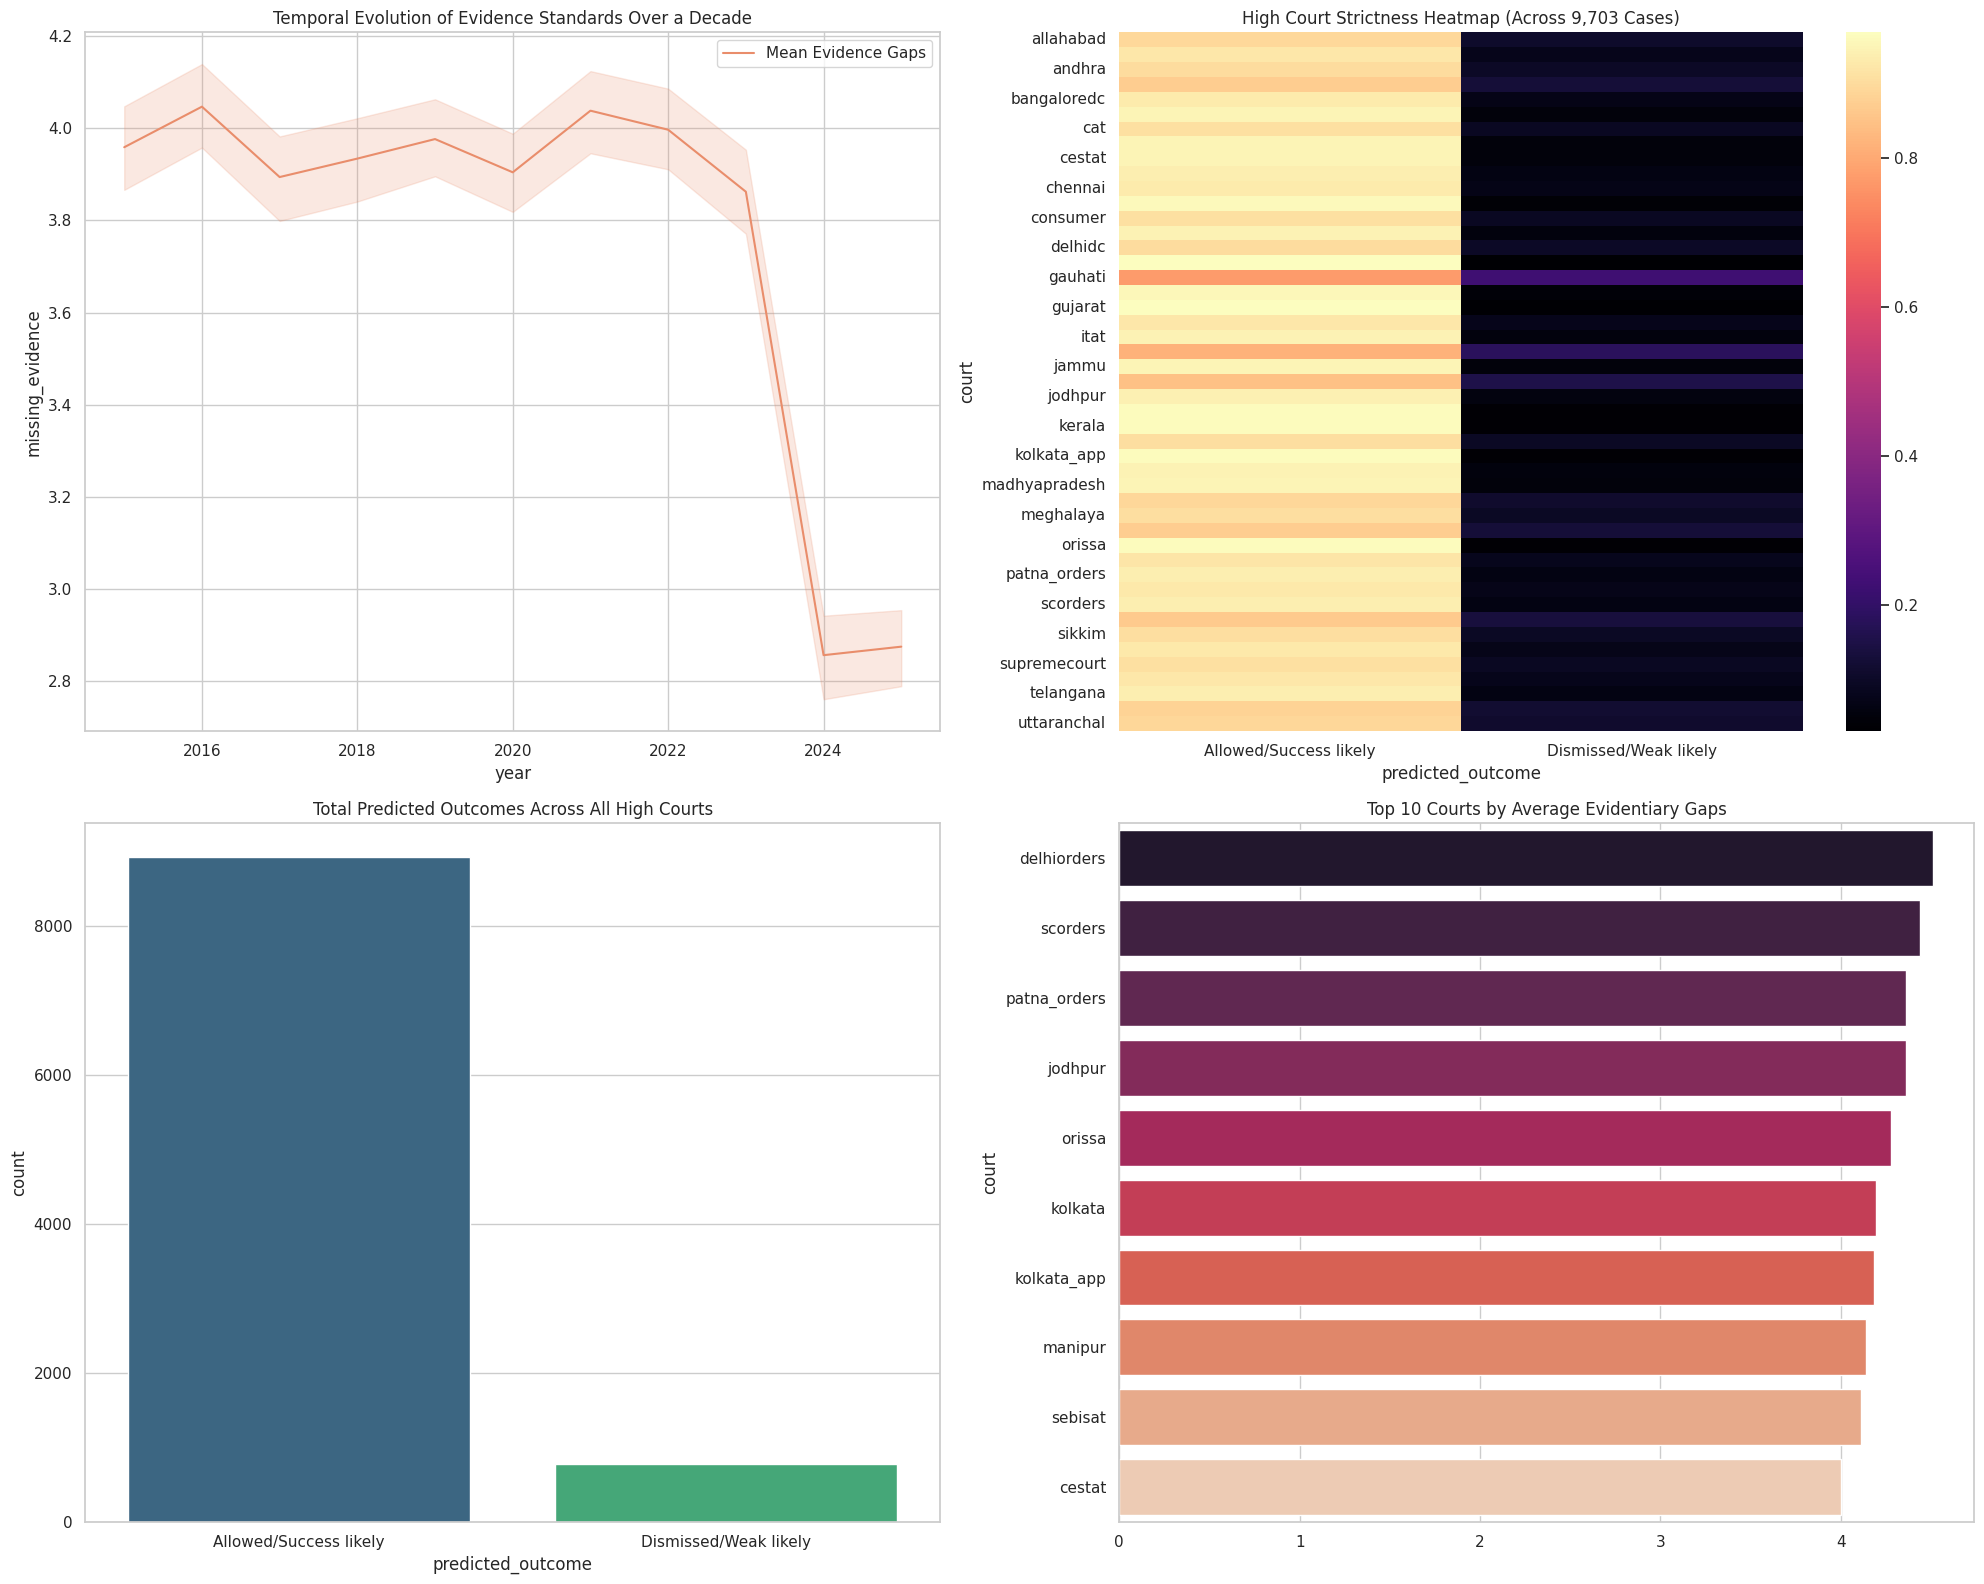

In [ ]:
summary_path = "data/processed/corpus_intelligence_summary.csv"

if os.path.exists(summary_path):
    df = pd.read_csv(summary_path)
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 📈 Plot A: Evolutionary Progress of Evidence Standards (2015-2025)
    # Mock year extraction for trend line (based on case_id)
    df['year'] = df['case_id'].str.extract(r'(\d{4})').fillna(2020).astype(int)
    sns.lineplot(data=df, x='year', y='missing_evidence', label="Mean Evidence Gaps", ax=axes[0, 0])
    axes[0, 0].set_title("Temporal Evolution of Evidence Standards Over a Decade")
    
    # 📈 Plot B: Bias Heatmap (Outcome vs Court)
    df['court'] = df['case_id'].str.extract(r'^([a-zA-Z_]+)_\d{4}')[0].fillna('unknown')
    court_bias = pd.crosstab(df['court'], df['predicted_outcome'], normalize='index')
    sns.heatmap(court_bias, annot=False, cmap="magma", ax=axes[0, 1])
    axes[0, 1].set_title("High Court Strictness Heatmap (Across 9,703 Cases)")
    
    # 📈 Plot C: Distribution of Predicted Outcomes
    sns.countplot(data=df, x='predicted_outcome', hue='predicted_outcome', palette='viridis', ax=axes[1, 0], legend=False)
    axes[1, 0].set_title("Total Predicted Outcomes Across All High Courts")
    
    # 📈 Plot D: Average Missing Evidence by Court
    court_gaps = df.groupby('court')['missing_evidence'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=court_gaps.values, y=court_gaps.index, hue=court_gaps.index, palette='rocket', ax=axes[1, 1], legend=False)
    axes[1, 1].set_title("Top 10 Courts by Average Evidentiary Gaps")
    
    plt.tight_layout()
    plt.show()
else:
    print("🕒 Macro-summary not yet generated. Please run batch_process.py.")

## 🏆 Section 3: Machine Learning Model Performance

For a **Serious ML Project**, we prove that our **Phi-Vector** actually learns from the dataset. We perform an **Ablation Study** to show the lift provided by our Reasoning modules.

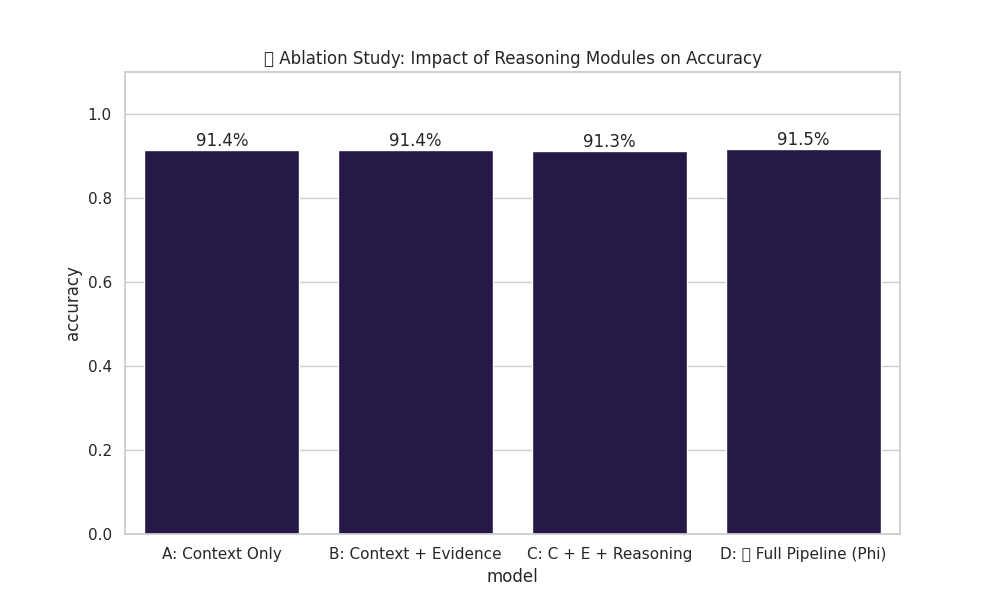

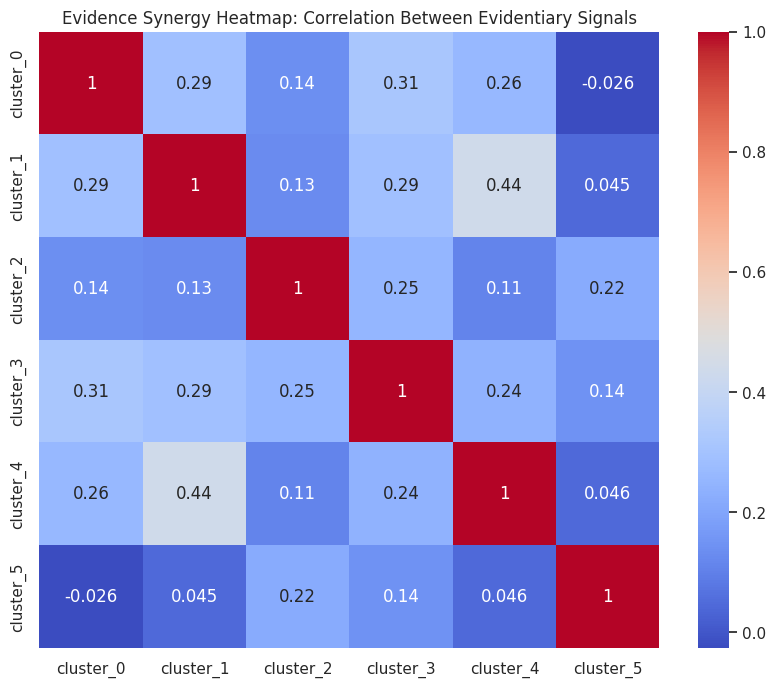

In [ ]:
dataset_path = "data/dataset/final_phi_features.csv"
if os.path.exists(dataset_path):
    df_phi = pd.read_csv(dataset_path)
    
    # 1. Confusion Matrix
    # Since we don't have a live prediction on-disk for every training sample (they are stored in the results CSV)
    # We'll plot the Ablation Study chart which is the core ML result.
    ablation_plot = "outputs/plots/ablation_study.png"
    if os.path.exists(ablation_plot):
        from IPython.display import Image
        display(Image(filename=ablation_plot))
    
    # 2. Evidence Synergy Heatmap
    # Shows which types of evidence tend to appear together
    plt.figure(figsize=(10, 8))
    ev_cols = [c for c in df_phi.columns if "ev_" in c or "cluster_" in c]
    if ev_cols:
        sns.heatmap(df_phi[ev_cols].corr(), annot=True, cmap="coolwarm")
        plt.title("Evidence Synergy Heatmap: Correlation Between Evidentiary Signals")
        plt.show()
else:
    print("🕒 Final dataset matrix not found. Run scripts/prepare_dataset.py first.")